In [ ]:
import importlib
import utils.functions as functions 
import utils.pre_processing as pre_processing
importlib.reload(pre_processing)
from utils.pre_processing import *
importlib.reload(functions)
from utils.functions import *


#org
import shutil 
import torch
import numpy as np
import warnings
import os, re, glob
from scipy import interpolate
import pandas as pd
from copy import deepcopy


#images
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import tifffile as tiff
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.ndimage import center_of_mass

#scientific libraries
from applefy.utils import flux_ratio2mag, mag2flux_ratio
from applefy.utils.photometry import AperturePhotometryMode
from applefy.detections.contrast import Contrast
from applefy.utils.photometry import AperturePhotometryMode
from applefy.statistics import TTest, gaussian_sigma_2_fpf, LaplaceBootstrapTest
from applefy.utils.positions import center_subpixel

from pathlib import Path
root_dir = Path(".")
print(root_dir)

/home/aosimul/noah/env_hci/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


.


# Test Stability of the Source

/tmp/ipykernel_3832793/2330327648.py:15: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(x,y, 8, 'k', '*', label = 'Center')
/tmp/ipykernel_3832793/2330327648.py:21: MatplotlibDeprecationWarning: Passing the marker parameter of scatter() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.scatter(x,y, 8, 'k', '*', label = 'Center')


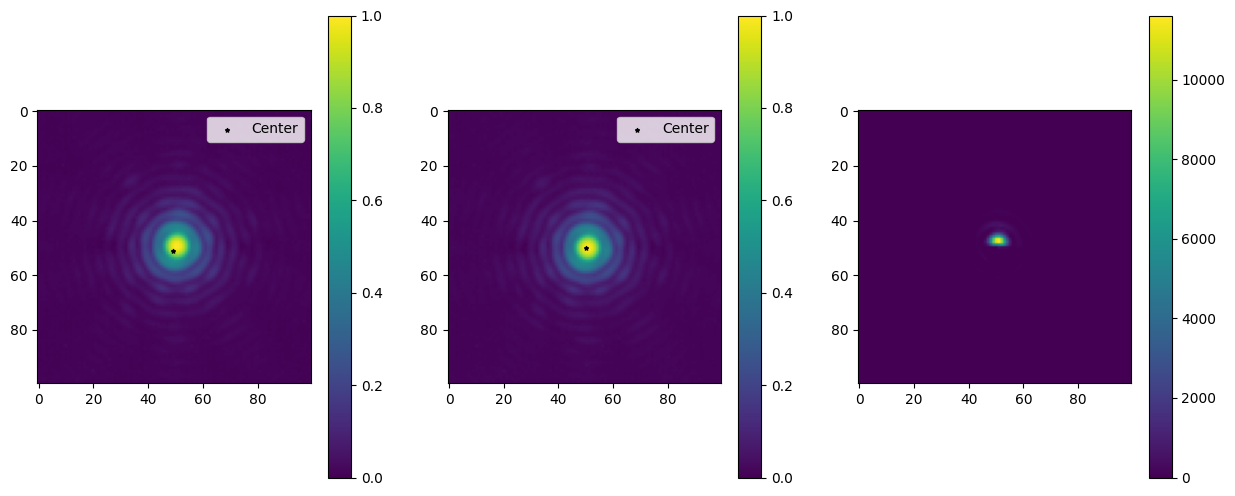

In [19]:
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_05/psf_unaberrated_2026-08-05T10-30-41.999_0.tif'
psf_1 = tiff.imread(glob.glob(f"{folder}"))
psf1 = np.median(psf_1, axis = 0)
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_05/psf_unaberrated_2026-08-05T15-50-14.42_0.tif'
psf_2 = tiff.imread(glob.glob(f"{folder}"))
psf2 = np.median(psf_2, axis = 0)

plt.figure(figsize = (15,6))
plt.subplot(133)
plt.imshow((psf1[50:-50, 50:-50] - psf2[50:-50, 50:-50]), vmin = 0)
plt.colorbar()
plt.subplot(131)
plt.imshow(np.log10(psf1[50:-50, 50:-50]))
x, y = np.unravel_index(np.argmax(psf1[50:-50, 50:-50]), psf1[50:-50, 50:-50].shape)
plt.scatter(x,y, 8, 'k', '*', label = 'Center')
plt.legend()
plt.colorbar()
plt.subplot(132)
plt.imshow(np.log10(psf2[50:-50, 50:-50]))
x, y = np.unravel_index(np.argmax(psf2[50:-50, 50:-50]), psf2[50:-50, 50:-50].shape)
plt.scatter(x,y, 8, 'k', '*', label = 'Center')
plt.legend()
plt.colorbar()

# Test display settings effect

I took 7 images where I changed the display mode (normal, logscale), and the contrast, and I want to check if it had any effect on the frames taken.

In [ ]:
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/test_display/'
#ros = [0.50, 0.70, 1.00]
test = np.concatenate([
    tiff.imread(
        sorted(glob.glob(f"{folder}*.tif"))
    )
    #for windspeed in ros
])
test  = test.astype(np.float32) #/ 65535

In [ ]:
test_croped = crop_stack(test)
print(test_croped.shape)

In [ ]:
plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
plt.imshow(np.mean(test_croped, axis = 0))
plt.colorbar(label = 'Counts')
plt.title('Mean PSF')

plt.subplot(1,2,2)
plt.imshow(np.std(test_croped, axis = 0), vmin =0)
plt.colorbar(label = 'Counts')
plt.title('STD PSF')

In [ ]:
test_croped  = test_croped.astype(np.float32) / 65535

plt.figure(figsize = (10,4))
plt.subplot(1,2,1)
plt.imshow(np.mean(test_croped, axis = 0))
plt.colorbar(label = 'Fraction of Saturation')
plt.title('Mean PSF')

plt.subplot(1,2,2)
plt.imshow(np.std(test_croped, axis = 0), vmin =0)
plt.colorbar(label = 'Fraction of Saturation')
plt.title('STD PSF')

plt.suptitle('Numerical error')

# Test Centering and Cropping

In [20]:
save_path = '/home/aosimul/noah/data/ghost_images/10_20ws/'
save_plot_path = '/home/aosimul/noah/results/animations/speckle_diversity/'
ori_folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_05/'

# Get all files
files = sorted(glob.glob(f"{ori_folder}*.tif"))

# Separate correctly
img_files = [
    f for f in files
    if "coro" in os.path.basename(f)
    and "no_coro" not in os.path.basename(f)
]

psf_files = [
    f for f in files
    if "no_coro" in os.path.basename(f)
]

psf_uncorelated = np.load('/home/aosimul/noah/data/ghost_images/10_20ws/psf_uncorrelated.npy')

print(f"Science images: {len(img_files)}")
print(f"PSF images: {len(psf_files)}")


Science images: 37
PSF images: 24


In [21]:
def plot_centers(stack,
                 reference_stack,
                 psf_uncorelated,
                 axis = 111,
                rad =4, 
                crop = 40,
                smooth_sigma = 2,                
                 ):

    img = stack[0, crop:-crop, crop:-crop] if crop is not None else stack[0]
    stack_croped = stack[:, crop:-crop, crop:-crop] if crop is not None else stack
    if isinstance(reference_stack, str):
        reference_stack = tiff.imread(glob.glob(f"{reference_stack}*.tif"))
        reference_stack = np.median(reference_stack, axis=0)
    reference_stack = reference_stack[crop:-crop, crop:-crop] if crop is not None else reference_stack
    ref_psf = gaussian_filter(reference_stack, smooth_sigma)


    method_labels = []
    centers = []
    colors = ['black', 'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive']

    # centers.append(center_subpixel(img))
    # method_labels.append('center of the image')

    # centers.append(estimate_center(stack_croped, 
    #            reference_stack = reference_stack, 
    #            method = 'cross_correlation',
    #            coords = None))
    # method_labels.append('Cross-Correlation')

    centers.append(estimate_center(stack_croped, 
               reference_stack = reference_stack, 
               method = 'fixed',
               coords = np.unravel_index(np.argmax(ref_psf), ref_psf.shape)))
    method_labels.append('maximum of the Gaussian PSF')

    centers.append(estimate_center(stack_croped, 
               reference_stack = reference_stack, 
               method = 'center_of_mass',
               coords = None))
    method_labels.append('Center of Mass')

    # centers.append(estimate_center(stack_croped, 
    #            reference_stack = reference_stack, 
    #            method = 'cross_correlation',
    #            coords = None))
    # method_labels.append('Cross Correlation')

    centers.append(estimate_center(stack_croped, 
               reference_stack = reference_stack, 
               method = 'gaussian',
               coords = None))
    method_labels.append('2D Gaussian')

    centers.append(estimate_center(stack_croped, 
               reference_stack = reference_stack, 
               method = 'masked_annulus',
               coords = None))
    method_labels.append('mask annulus')

    plt.subplot(axis)
    plt.imshow(np.log10(img), cmap='viridis', vmin = -3, vmax = 0)
    plt.colorbar(label='Fraction of Saturation')
    for i, (cx, cy) in enumerate(centers):
        cx, cy = float(cx), float(cy)
        plt.plot(
            cx,
            cy,
            marker="*",
            markersize=8,
            markerfacecolor= colors[i],
            markeredgecolor= colors[i],
            linestyle="None",
            zorder=20,
            label = method_labels[i],
            alpha = 0.6
        )


        plt.gca().add_patch(Circle(
            (cx, cy),
            rad,
            fill=False,
            edgecolor= colors[i],
            linewidth=1.,
            linestyle="--",
            zorder=10,
        ))

    plt.title('Unaberrated PSF Image')
    plt.legend(loc='upper right', fontsize = 8.0)
    #plt.show()

#plot_centers(psf_uncorelated)

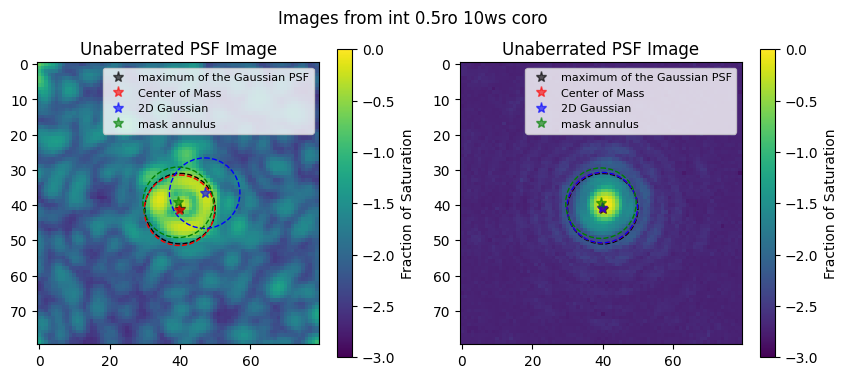

/home/aosimul/noah/notebooks/utils/pre_processing.py:151: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(_rotated_gaussian, (X, Y), im.ravel(), p0=p0, maxfev=maxfev)


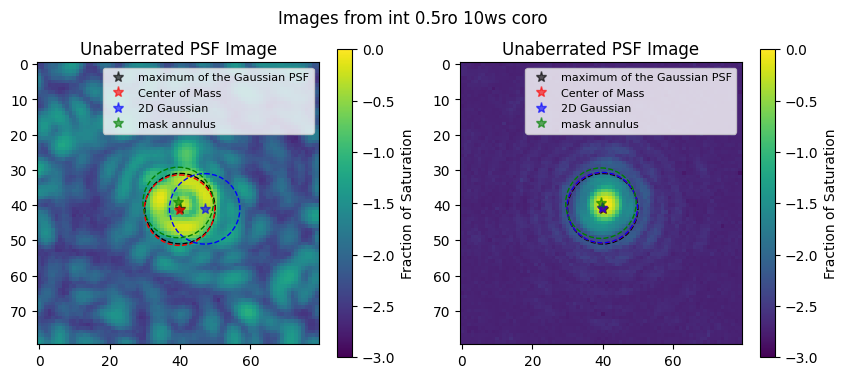

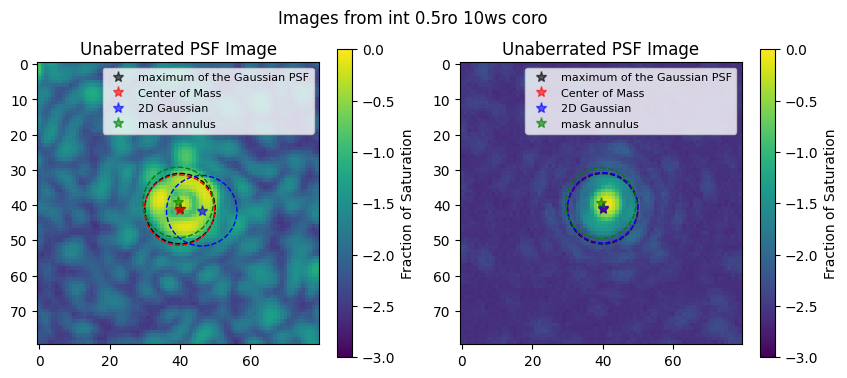

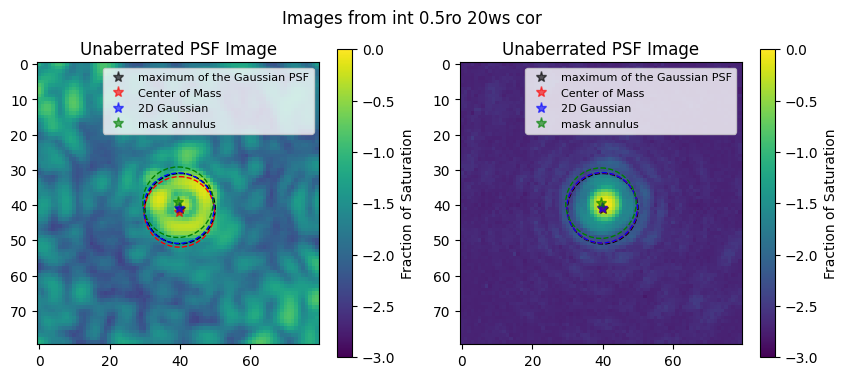

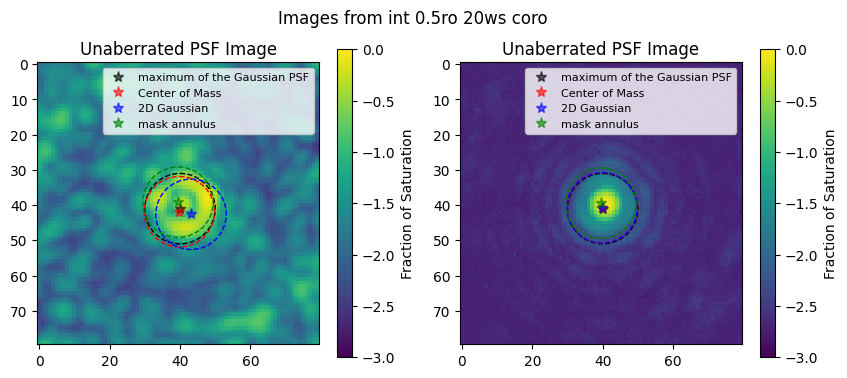

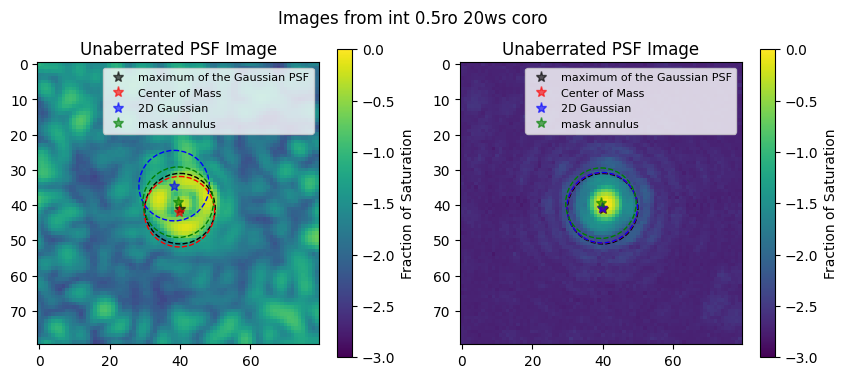

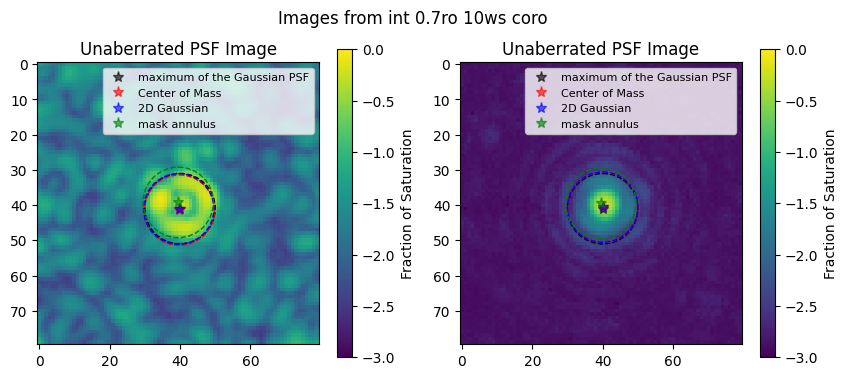

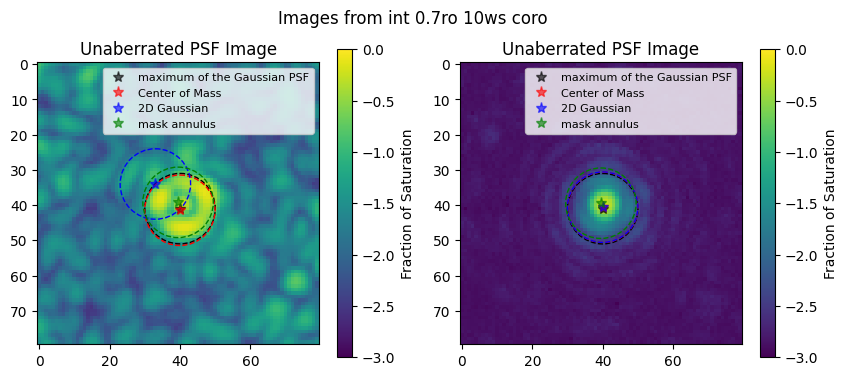

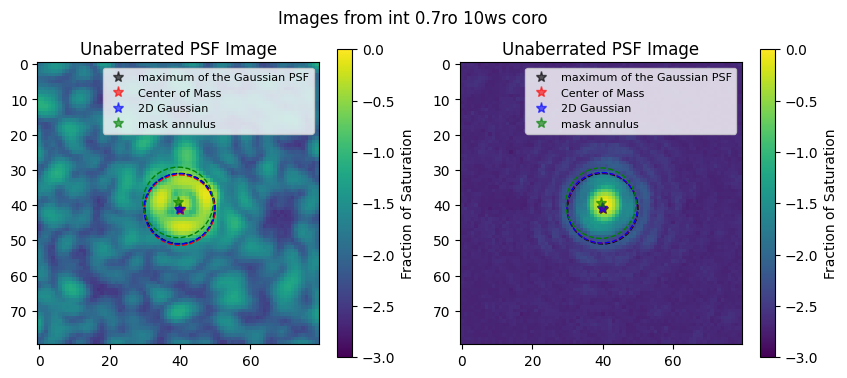

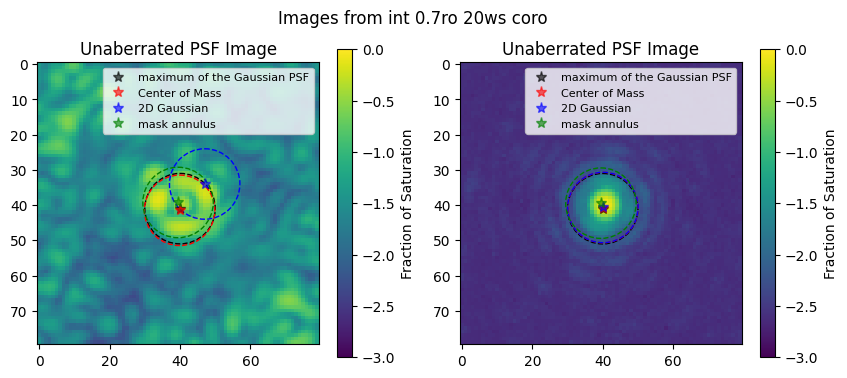

KeyboardInterrupt: 

<Figure size 1000x400 with 0 Axes>

In [22]:
crop = 60
rad = 10
smooth_sigma = 2
ref = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/psf_uncorrolated_2'

for i, img_file in enumerate(img_files):
    # Get the corresponding PSF file
    mod = i%3
    psf_file = psf_files[i - mod] if mod < 2 else psf_files[i - mod - 1]

    if psf_file is None:
        print(f"No corresponding PSF file found for {img_file}")
        continue

    # Load images
    img = tiff.imread(img_file).astype(np.float32)
    psf = tiff.imread(psf_file).astype(np.float32)

    #aligned
    aligned_stack = align_stack(img)
    aligned_psf = align_stack(psf)
    # Crop images
    # img_croped = crop_stack(img)
    # psf_croped = crop_stack(psf)

    # Normalize images
    aligned_stack /= np.max(aligned_stack)
    aligned_psf /= np.max(aligned_psf)

    # Plotting
    plt.figure(figsize=(10, 4))
    
    
    plot_centers(aligned_stack,
                 reference_stack = np.mean(aligned_psf, axis=0),
                 psf_uncorelated = psf_uncorelated,
                 axis = 121,
                 rad =rad, 
                crop = crop,
                smooth_sigma = smooth_sigma
                )
    # plt.imshow(np.log10(np.mean(img_croped, axis=0)))
    # plt.colorbar(label='Fraction of Saturation')
    # plt.title('Mean Science Image')

    
    plot_centers(aligned_psf, 
                 reference_stack = np.mean(aligned_psf, axis=0),
                 psf_uncorelated = psf_uncorelated,
                 axis = 122,
                 rad =rad, 
                 crop = crop,
                 smooth_sigma = smooth_sigma
                )
    # plt.imshow(np.log10(np.mean(psf_croped, axis=0)))
    # plt.colorbar(label='Fraction of Saturation')
    # plt.title('Mean PSF Image')

    plt.suptitle(f'Images from {os.path.basename(img_file)[:-30].replace('_', ' ')}')
    
    # Save the plot
    # save_plot_name = os.path.join(save_plot_path, f"{os.path.basename(img_file).replace('.tif', '_mean.png')}")
    # plt.savefig(save_plot_name)
    # plt.close()
    plt.show()

# Pre-Processing of one stack

- Create master dark frame: median of 3500 dark frames of 25ms, in counts
- Center
- Crop
- Subtract df
- divide by 65535


In [ ]:
radius = 55

In [ ]:
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/darks_2026-07-22T10-28-49.8'
df = tiff.imread(glob.glob(f"{folder}*.tif"))
#df  = df.astype(np.float32) #/ 65535
df = crop_stack(df, radius = radius)
master_df = np.median(df, axis = 0)
print(master_df.shape)

In [ ]:
folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/psf'
sci_img = tiff.imread(glob.glob(f"{folder}*.tif"), key=range(3500))
sci_img = crop_stack(sci_img,  radius = radius)
sci_img_processed = (sci_img - master_df) 
sci_img_processed  = sci_img_processed.astype(np.float32) / 65535
#np.save(f'/home/aosimul/noah/data/ghost_images/25ms/coro_int_0.70ro_12.50ws.npy', sci_img_processed.astype(np.float32))

# folder      = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_17/non_coro_int_0.70ro_12.50ws'
# sci_img = tiff.imread(glob.glob(f"{folder}*.tif"), key=range(3500))
# sci_img = crop_stack(sci_img,  radius = radius)
# sci_img_processed = (sci_img - master_df) 
# sci_img_processed  = sci_img_processed.astype(np.float32) / 65535
# #np.save(f'/home/aosimul/noah/data/ghost_images/25ms/non_coro_int_0.70ro_12.50ws.npy', sci_img_processed.astype(np.float32))


print(sci_img_processed.shape)

In [ ]:
# non_coro_int  = np.load('/home/aosimul/noah/data/ghost_images/25ms/non_coro_int_0.70ro_12.50ws.npy')
# non_coro_int = np.load('/home/aosimul/noah/data/ghost_images/25ms/coro_int_0.70ro_12.50ws.npy')
# print(non_coro_int.shape, non_coro_int.shape)

In [ ]:
plt.figure(figsize = (10,14))

plt.subplot(3,2,1)
plt.imshow(master_df)
plt.colorbar(label = 'Counts')
plt.title('Master median dark frame')

plt.subplot(3,2,2)
plt.imshow(np.std(df, axis = 0))
plt.colorbar(label = 'Counts')
plt.title('STD dark frame')

plt.subplot(3,2,3)
plt.imshow(np.log10(np.mean(sci_img, axis = 0)))
plt.colorbar(label = 'Log Counts')
plt.title(f'Raw Mean Image')

plt.subplot(3,2,4)
plt.imshow(np.log10(np.mean(sci_img_processed, axis = 0)*65535))
plt.colorbar(label = f'Log Counts')
plt.title(f'Pre-Processed Mean Image')

cutoff = 20
plt.subplot(3,2,5)
plt.imshow((np.mean(sci_img, axis = 0))[:cutoff, :cutoff])
plt.colorbar(label = ' Counts')
plt.title(f'Raw Mean Image \nBackground [0:{cutoff}, 0:{cutoff}]')

plt.subplot(3,2,6)
plt.imshow((np.mean(sci_img_processed, axis = 0))[:cutoff, :cutoff]*65535)
plt.colorbar(label = f' Counts')
plt.title(f'Pre-Processed Mean Image \nBackground [0:{cutoff}, 0:{cutoff}]')

# Speckle Diversity

## Method Testing

In [ ]:


folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/'
sci_img_processed = run_pre_processing_with_outliers(img_file = f'{folder}int_0.5ro_10ws_coro', 
                       img_key = 6667, 
                       dark_file = f'{folder}darks',  
                       dark_key= 8475, 
                       ref_psf=f'{folder}psf', 
                       radius = 55,
                       coords= None
                       )

In [ ]:
frames = sci_img_processed

n_frames = frames.shape[0]

# Flatten frames
X = frames.reshape(n_frames, -1).astype(float)

# Mean-center each pixel across the dataset
X -= X.mean(axis=0)



In [ ]:
# PCA (SVD solver)
n_components = 5
pca = PCA(n_components=n_components, svd_solver="full")
pca_coords = pca.fit_transform(X)

#took 2m16s

In [ ]:
# PCA (SVD solver)
n_components = 3
pca2 = PCA(n_components=n_components, svd_solver="full")
pca_coords2 = pca2.fit_transform(X)

#took 2m

In [ ]:
# PCA (SVD randomised solver)
n_components = 5
pca3 = PCA(n_components=n_components, svd_solver="randomized", random_state=42,
)
pca_coords3 = pca3.fit_transform(X)

#took 1.5s

In [ ]:
print(pca_coords)
print(pca_coords2)
print(pca_coords3)

In [ ]:
# Normalise
pca_coords /= np.max(np.abs(pca_coords), axis=0)
pca_coords3 /= np.max(np.abs(pca_coords3), axis=0)





In [ ]:
# Median and MAD along each PCA axis
medians = np.median(pca_coords, axis=0)
mads = np.median(np.abs(pca_coords - medians), axis=0)

medians3 = np.median(pca_coords3, axis=0)
mads3 = np.median(np.abs(pca_coords3 - medians3), axis=0)

In [ ]:

# Avoid division by zero
mads[mads == 0] = 1e-10
mads3[mads3 == 0] = 1e-10
mad_threshold = 5
# Outlier detection
deviation = np.abs(pca_coords - medians)

outlier_matrix = deviation > mad_threshold * mads

bad_mask = np.any(outlier_matrix, axis=1)
good_mask = ~bad_mask

deviation3 = np.abs(pca_coords3 - medians3)

outlier_matrix3 = deviation3 > mad_threshold * mads3

bad_mask3 = np.any(outlier_matrix3, axis=1)
good_mask3 = ~bad_mask3

In [ ]:


# good_mask, bad_mask, outlier_matrix, pca_coords, medians, mads = pca_frame_selection(
#     sci_img_processed,
#     n_components=3,
#     mad_threshold=5,
# )

# #Which PCA rejected each frame
# bad_components = [
#     np.where(outlier_matrix[i])[0]
#     for i in range(len(outlier_matrix))
# ]


fig, ax = plot_pca_frame_selection(
    pca_coords,
    bad_mask,
    medians,
    mads,
    mad_threshold=5,
)

fig, ax = plot_pca_frame_selection(
    pca_coords3,
    bad_mask3,
    medians3,
    mads3,
    mad_threshold=5,
)

In [ ]:
different = bad_mask != bad_mask3
different_idx = np.where(different)[0]

print(f"{different.sum()} frames differ.")

In [ ]:
# Rejected only by PCA
bad_with_full = bad_mask & ~bad_mask3

# Rejected only by old method
bad_with_trunc = bad_mask3 & ~bad_mask

In [ ]:

cube = sci_img_processed
idx = np.where(different)[0]

ncols = 4
nrows = int(np.ceil(len(idx)/ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4*ncols,4*nrows),                         
                         constrained_layout=True)

axes = np.atleast_1d(axes).ravel()

# Use a common normalization for all images
vmin = cube[idx].min()
vmax = cube[idx].max()

im = None
for ax, i in zip(axes, idx):

    im = ax.imshow(
        np.log10(cube[i]),
        origin="lower",
        cmap="gray",
        vmin=np.log10(vmin),
        vmax=np.log10(vmax),
    )

    title = []
    if bad_with_full[i]:
        title.append("bad_with_full only")
    if bad_with_trunc[i]:
        title.append("bad_with_trunc only")

    ax.set_title(f"Frame {i}\n{' '.join(title)}")
    ax.axis("off")

# Remove unused axes
for ax in axes[len(idx):]:
    fig.delaxes(ax)

# One common colorbar
cbar = fig.colorbar(
    im,
    ax=axes[:len(idx)],
    shrink=0.85,
    pad=0.02,
)
cbar.set_label("Pixel value")

plt.suptitle('Compare Full SVD outlier detection to Randomised Truncated SVD')
plt.show()

## Test Pre_processing routine

In [ ]:
folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/'
sci_img_processed_no_outlier, outlier_matrix = run_pre_processing(img_file = f'{folder}int_0.5ro_10ws_coro', 
                       img_key = 6667, 
                       dark_file = f'{folder}darks',  
                       dark_key= 8475, 
                       ref_psf=f'{folder}psf', 
                       radius = 55,
                       coords= None,
                       n_components=3,
                       mad_threshold=7,
                       PCA_analysis = True
                       )

In [ ]:
folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/7_22/'
sci_img_processed = run_pre_processing_with_outliers(img_file = f'{folder}int_0.5ro_10ws_coro', 
                       img_key = 6667, 
                       dark_file = f'{folder}darks',  
                       dark_key= 8475, 
                       ref_psf=f'{folder}psf', 
                       radius = 55,
                       coords= None
                       )

In [ ]:

def plot_outlier_images_by_pc(
    cube,
    outlier_matrix,
    cmap="inferno",
):
    """
    Plot all outlier images grouped by PCA component.

    Parameters
    ----------
    cube : ndarray
        Image cube (n_frames, ny, nx)
    outlier_matrix : ndarray
        Boolean array (n_frames, n_components)
    """

    n_components = outlier_matrix.shape[1]

    # Global normalization over ALL outlier images
    all_indices = np.where(np.any(outlier_matrix, axis=1))[0]

    if len(all_indices) == 0:
        print("No outliers found.")
        return

    data = cube[all_indices]

    # Log scale requires positive values
    vmin = np.percentile(data[data > 0], 1)
    vmax = np.percentile(data[data > 0], 99.5)

    norm = LogNorm(vmin=vmin, vmax=vmax)


    for pc in range(n_components):

        indices = np.where(outlier_matrix[:, pc])[0]

        if len(indices) == 0:
            continue

        ncols = 6
        nrows = int(np.ceil(len(indices) / ncols))

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(3*ncols, 3*nrows),
        )

        axes = np.atleast_1d(axes).ravel()

        im = None

        for ax, idx in zip(axes, indices):

            # avoid zero values for LogNorm
            image = np.maximum(cube[idx], vmin)

            im = ax.imshow(
                image,
                origin="lower",
                cmap=cmap,
                norm=norm,
            )

            ax.set_title(f"Frame {idx}")
            ax.axis("off")


        # remove unused panels
        for ax in axes[len(indices):]:
            ax.remove()


        # one colorbar for this PC group
        cbar = fig.colorbar(
            im,
            ax=axes[:len(indices)],
            fraction=0.02,
            pad=0.02,
        )

        cbar.set_label("Intensity (log scale)")


        fig.suptitle(
            f"Outliers detected by PC{pc+1} "
            f"({len(indices)} frames)",
            fontsize=16,
        )

        plt.show()

In [ ]:
plot_outlier_images_by_pc(
sci_img_processed, outlier_matrix
)

# Run pre-processing on all images

In [2]:
save_path = '/home/aosimul/noah/data/ghost_images/10_20ws_2/'
save_plot_path = '/home/aosimul/noah/results/animations/speckle_diversity/batch_2'
ori_folder = '/home/aosimul/noah/data/ghost_images/phase_screens_SLM/8_05/'

# Get all files
files = sorted(glob.glob(f"{ori_folder}*.tif"))

# Separate correctly
img_files = [
    f for f in files
    if "coro" in os.path.basename(f)
    and "no_coro" not in os.path.basename(f)
]

psf_files = [
    f for f in files
    if "no_coro" in os.path.basename(f)
]


print(f"Science images: {len(img_files)}")
print(f"PSF images: {len(psf_files)}")



Science images: 37
PSF images: 24


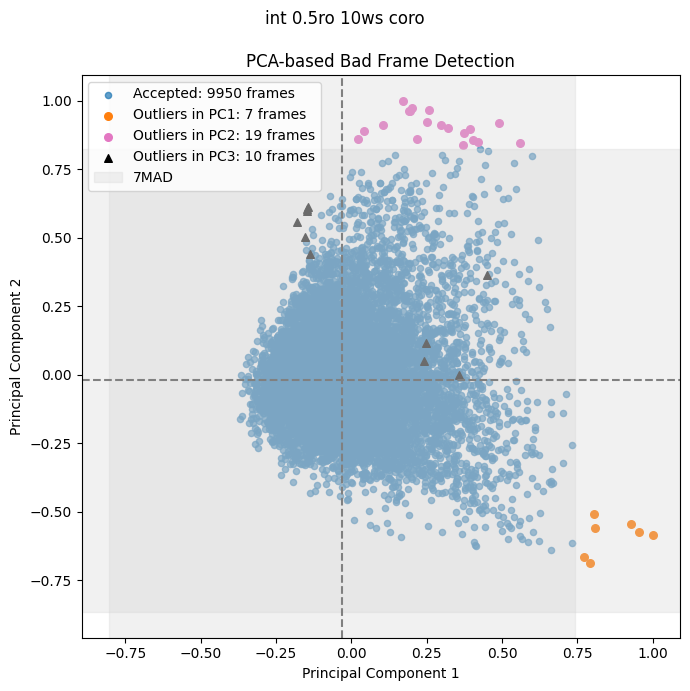

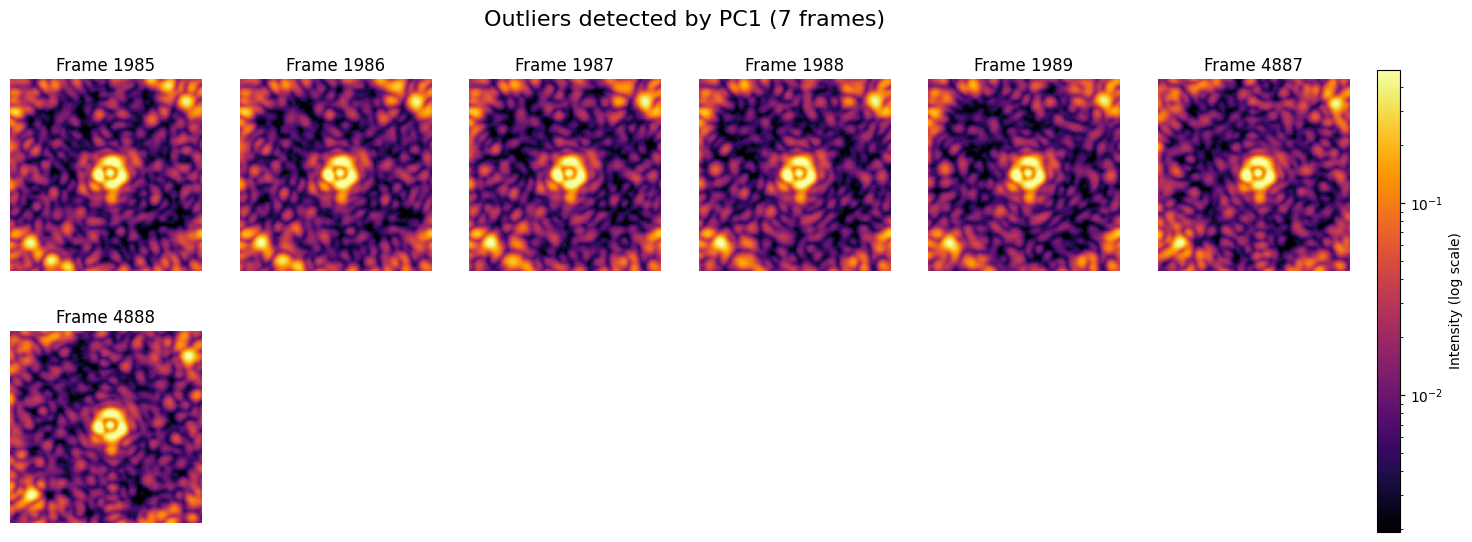

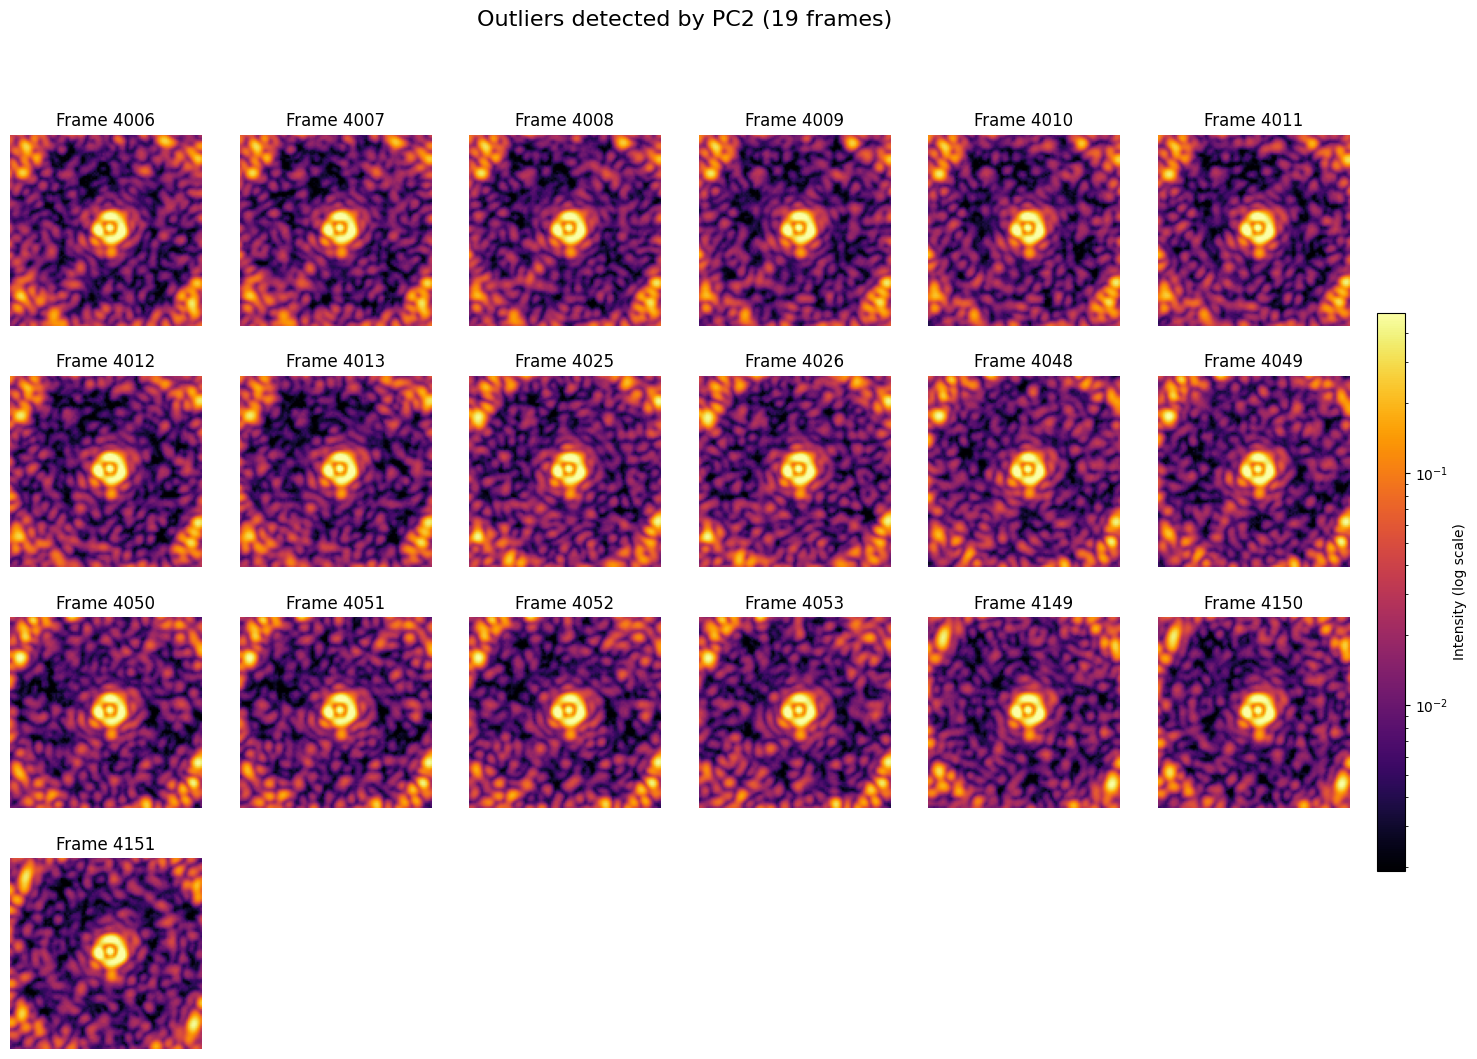

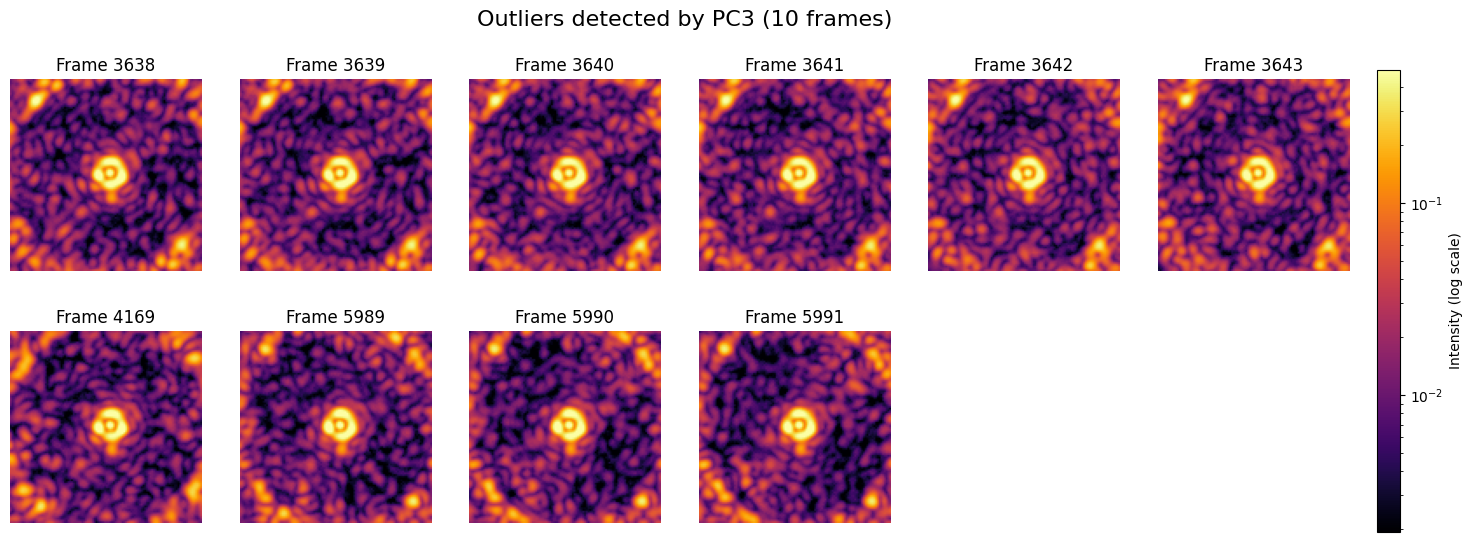

No outliers found.


NameError: name 'psf_file' is not defined

In [ ]:
psf_count = 0

for i, img_file in enumerate(img_files):

    # 1) Align, center and crop
    sci_img_processed = run_pre_processing(img_file = ori_folder + Path(img_file).stem,
                    img_key = 9986, 
                    dark_file = f'{ori_folder}darks_img',  
                    dark_key= 10000, 
                    ref_psf=f'{ori_folder}psf_', 
                    radius = 55,
                    method='masked_annulus',
                    )
    # 2) Detect outliers
    sci_img_processed_no_outlier, outlier_matrix = run_outlier_detection(img_file = ori_folder + Path(img_file).stem, 
                        sci_img_processed = sci_img_processed, 
                        n_components=3,
                        mad_threshold=7,
                        PCA_analysis = True,
                        PCA_plot_output= save_plot_path,
                        )
    plot_outlier_images_by_pc(
        sci_img_processed, outlier_matrix
        )
    
    # 3) Save the file
    name = os.path.basename(img_file)          # int_1.0ro_10ws_no_coro_2026-07-22T11-24-21.543_0
    
    save_name = name.split("_coro")[0]  # int_1.0ro_10ws_no_coro
    filename = os.path.join(save_path, f"{save_name}.npy")

    counter = 1
    while os.path.exists(filename):
        filename = os.path.join(
            save_path,
            f"{save_name}_{counter}.npy"
        )
        counter += 1

    np.save(filename, sci_img_processed_no_outlier)


    # 4) Do the sme if psf corresponds
    # 4.1) Check if need to do psf
    mod = i%3
    if mod != 2:
        psf_img_processed = run_pre_processing(img_file = ori_folder + Path(psf_files[psf_count]).stem, 
                            img_key = 10000, 
                            dark_file = f'{ori_folder}darks_psf',  
                            dark_key= 10000, 
                            ref_psf=f'{ori_folder}psf_', 
                            radius = 55,
                            method='gaussian',
                            )
        # 4.2) Detect outliers
        psf_img_processed_no_outlier, outlier_matrix = run_outlier_detection(img_file = ori_folder + Path(img_file).stem, 
                            sci_img_processed = psf_img_processed, 
                            n_components=3,
                            mad_threshold=7,
                            PCA_analysis = False,
                            PCA_plot_output= save_plot_path,
                            )
        plot_outlier_images_by_pc(
            psf_img_processed, outlier_matrix
            )
        
        # 4.3) Save the file
        psf_med = np.mean(psf_img_processed_no_outlier, axis = 0)
        name = os.path.basename(psf_file)          # int_1.0ro_10ws_no_coro_2026-07-22T11-24-21.543_0
        
        save_name = name.split("_no")[0]  # int_1.0ro_10ws_no_coro
        filename = os.path.join(save_path, f"psf_{save_name}.npy")

        counter_psf = 1
        while os.path.exists(filename):
            filename = os.path.join(
                save_path,
                f"psf_{save_name}_{counter}.npy"
            )
            counter_psf += 1
    # name = os.path.basename(psf_file)          # int_1.0ro_10ws_no_coro_2026-07-22T11-24-21.543_0
    # save_name = name.split("_no")[0]  # int_1.0ro_10ws_no_coro
    # np.save(f'{save_path}psf_{save_name}.npy', psf_med)
        np.save(filename, psf_med) 

        psf_count += 1

    # 5) Run some analysis
    
    



psf_uncorelated = run_pre_processing(img_file = ori_folder + 'psf', 
                    img_key = 8475, 
                    dark_file = f'{ori_folder}darks_psf',  
                    dark_key= 10000, 
                    ref_psf=f'{ori_folder}psf', 
                    radius = 55
                    )
psf_med = np.mean(psf_uncorelated, axis = 0)
np.save(f'{save_path}psf_uncorrelated.npy', psf_med)